In [2]:
import rclpy
import rclpy.logging
from rclpy.node import Node
from actuator_msgs.msg import Actuators
from std_msgs.msg import Header

from rclpy.qos import QoSProfile, ReliabilityPolicy, HistoryPolicy, DurabilityPolicy
from nav_msgs.msg import Odometry

import numpy as np
import math
from collections import deque

In [3]:
import pandas as pd
from pydrake.all import LinearQuadraticRegulator, DiscreteTimeLinearQuadraticRegulator
from scipy.optimize import root
import mplcursors

In [4]:
mass = 1.5 + 0.015 + 0.005 * 4
mass

1.535

In [5]:
Ixx_B = 0.029125+0.00001
Iyy_B = 0.029125+0.00001
Izz_B = 0.055225+0.00001

Ixx_P = 9.75e-07
Iyy_P = 0.000273104
Izz_P = 0.000273104

Ixx_t = Ixx_B + 4 * Ixx_P
Iyy_t = Iyy_B + 4 * Iyy_P
Izz_t = Izz_B + 4 * Izz_P
Ixx_t, Iyy_t, Izz_t

(0.029138900000000002, 0.030227416, 0.056327416000000005)

In [6]:
l = math.sqrt(0.13**2 + 0.22**2)
l

0.25553864678361277

In [7]:
global KF, Y
# KF = 5.84e-06 #sdf
KF = 11.68e-06 #sdf
KT = 0.06  #sdf
Y = 2.75e-3     #paper


In [8]:
def quaternion_to_rpy(w, x, y, z):
    """
    Convert quaternion to roll, pitch, and yaw (RPY) angles.
    
    Parameters:
    - x: float, x component of the quaternion
    - y: float, y component of the quaternion
    - z: float, z component of the quaternion
    - w: float, w component of the quaternion
    
    Returns:
    - roll: float, roll angle in radians
    - pitch: float, pitch angle in radians
    - yaw: float, yaw angle in radians
    """
    
    # Roll (x-axis rotation)
    sinr_cosp = 2 * (w * x + y * z)
    cosr_cosp = 1 - 2 * (x * x + y * y)
    roll = math.atan2(sinr_cosp, cosr_cosp)

    # Pitch (y-axis rotation)
    sinp = 2 * (w * y - z * x)
    if abs(sinp) >= 1:
        pitch = math.copysign(math.pi / 2, sinp)  # Use 90 degrees if out of range
    else:
        pitch = math.asin(sinp)

    # Yaw (z-axis rotation)
    siny_cosp = 2 * (w * z + x * y)
    cosy_cosp = 1 - 2 * (y * y + z * z)
    yaw = math.atan2(siny_cosp, cosy_cosp)

    return roll, pitch, yaw

In [9]:
class CommandPublisherNode(Node):
    def __init__(self):
        super().__init__('command_publisher_node')
        self.logger = self.get_logger()
        self.motor_command_pub = self.create_publisher(Actuators, '/iris_px4/command/motor_speed', 10)
        
        qos_profile = QoSProfile(
            reliability=ReliabilityPolicy.BEST_EFFORT,
            durability=DurabilityPolicy.VOLATILE,
            history=HistoryPolicy.KEEP_LAST,
            depth=5
        )
        
        # Create subscription with proper QoS
        self.subscription = self.create_subscription(
            Odometry,
            '/iris_px4/odometry',
            self.odometry_callback,
            qos_profile)
        self.initialize_params()
        
    def initialize_params(self):        
        self.actuators_msg = Actuators()
        self.actuators_msg.header = Header()
        self.actuators_msg.header.stamp = self.get_clock().now().to_msg()
        self.actuators_msg.header.frame_id = ''
        self.actuators_msg.velocity = [float(0), float(0), float(0), float(0)]
                
        # Initialize class attributes
        self.clock_time = self.get_clock().now()
        self.x = self.y = self.z = 0.0
        self.vx = self.vy = self.vz = 0.0
        self.prev_vx = self.prev_vy = self.prev_vz = 0.0
        self.ax = self.ay = self.az = 0.0
        self.roll = self.pitch = self.yaw = 0.0
        
        # Previous velocities for acceleration calculation
        self.prev_vx = self.prev_vy = self.prev_vz = 0.0
        
        # Create a rate
        self.frequency = 100
        self.rate = self.create_rate(self.frequency) 
        
        # motor commands
        self.command_values = [0.0, 0.0, 0.0, 0.0]
        self.to_measure_Y = False      #torque coeff
        self.to_measure_KF = False      #force coeff
        self.measurement_queue = deque(maxlen=10)
        self.counter = 0
        # for force coeff
        self.avg_acc_error_tol = 0.01
        self.avg__w__error_tol = 0.001
        self.prev_value = 0.0
        self.to_stop_spin = False
        
    def calculate_accelerations(self):
        """Calculate accelerations from velocity changes"""
        curr_time = self.get_clock().now()
        del_t = curr_time.seconds_nanoseconds()[0]-self.clock_time.seconds_nanoseconds()[0] + 1e-9 * (curr_time.seconds_nanoseconds()[1]-self.clock_time.seconds_nanoseconds()[1])
        if del_t > 0:
            self.ax = (self.vx - self.prev_vx) / del_t
            self.ay = (self.vy - self.prev_vy) / del_t
            self.az = (self.vz - self.prev_vz) / del_t  
            
    def odometry_callback(self, msg):
        # Position
        self.x = msg.pose.pose.position.x
        self.y = msg.pose.pose.position.y
        self.z = msg.pose.pose.position.z
        # Orientation
        _q = msg.pose.pose.orientation
        self.rpy = list(quaternion_to_rpy(_q.w, _q.x, _q.y, _q.z))
        # Linear velocities
        self.vx = msg.twist.twist.linear.x
        self.vy = msg.twist.twist.linear.y
        self.vz = msg.twist.twist.linear.z
        # Angular velocities
        self.wx = msg.twist.twist.angular.x
        self.wy = msg.twist.twist.angular.y
        self.wz = msg.twist.twist.angular.z
        # self.logger.info(f'{self.z}')
        if self.to_measure_KF:
            self.calculate_accelerations()
            self.average_calculation(self.az, self.avg_acc_error_tol, self.calculate_KF)
            
        if self.to_measure_Y:
            self.average_calculation(self.wz, self.avg__w__error_tol, self.calculate_Y)
                
    def average_calculation(self, x, x_tol, calculate_var):
        if self.counter == 10:
            value = sum(self.measurement_queue) / self.measurement_queue.maxlen
            self.logger.info(f'average vale in z = {value}, prev_value: {self.prev_value}')
            self.counter = 0
            self.logger.info(f'{value - self.prev_value}, {x_tol}, {abs(value - self.prev_value) <= x_tol}')
            if(abs(value - self.prev_value) <= x_tol):
                self.logger.info('starting calculation of constants')
                calculate_var(value)
                self.logger.info('Done!!')
            self.prev_value = value
        self.counter += 1
        self.measurement_queue.append(x)
        
    def calculate_KF(self, avg_acc):
        global KF
        KF = mass * (avg_acc + 9.8) / 4 / self.command_values[0]**2     #same values in all 4 rotors
        self.logger.info(f'Calculated Value of Force coeff of a single motor: {KF}')
        self.to_stop_spin = True
        
    def calculate_Y(self, avg_w):
        global Y
        W2 = [v**2 for v in self.command_values]
        torque = KF * KT * (W2[0] + W2[1] - W2[2] - W2[3])       #same values in 2 diagonal rotors
        # drag coeff = net torque / angular vel of the drone about z axis 
        Y = abs(torque) / abs(avg_w)
        self.logger.info(f'Calculated Value of drag coeff of the drone: {Y}')
        self.to_stop_spin = True
    
    def command_pub(self, cmd: list):
        assert len(cmd) == 4
        self.command_values = cmd
        self.actuators_msg.header.stamp = self.get_clock().now().to_msg()
        self.actuators_msg.velocity = [float(v) for v in cmd]
        self.motor_command_pub.publish(self.actuators_msg)
        
        

To measure Force coeff, make sure the drone is launched in gazebo with a prismatic joint in z direction.

In [10]:
rclpy.init()
commander = CommandPublisherNode()

In [11]:
# commander.to_measure_KF = True

In [12]:
# thrust_value = 550
# commander.command_pub([thrust_value for i in range(4)])

Make sure the propellers are rotating in Gazebo, if yes, then only move forward

In [13]:
# while rclpy.ok():
#     rclpy.spin_once(commander, timeout_sec=0.01)
#     if commander.to_stop_spin:
#         break
# commander.initialize_params()
# rclpy.shutdown()
# commander.destroy_node()

To measure moment coeff, make sure the drone is launched in gazebo with a revolute joint in z direction.

In [14]:
# rough
# KT = Izz_t * abs(0.3269074058596694) / KF / 4 / 200**2
# KT

In [15]:
# commander.to_measure_KT = True

In [16]:
# thrust_value = 100
# commander.command_pub([thrust_value if i<2 else -thrust_value for i in range(4)])

Make sure the propellers are rotating in Gazebo, if yes, then only move forward

In [17]:
# while rclpy.ok():
#     rclpy.spin_once(commander, timeout_sec=0.01)
#     if commander.to_stop_spin:
#         break
# commander.initialize_params()

To measure gamma coeff, make sure the drone is launched in gazebo with a revolute joint in z direction.

In [18]:
# commander.to_measure_Y = True

In [19]:
thrust_value = 200
commander.command_pub([thrust_value if i<2 else 0.0 for i in range(4)])

Make sure the propellers are rotating in Gazebo, if yes, then only move forward

In [20]:
################################################
# Too much corrupted values :)

# while rclpy.ok():
#     rclpy.spin_once(commander, timeout_sec=0.01)
#     if commander.to_stop_spin:
#         break
# commander.initialize_params()

In [21]:
commander.command_values

[200, 200, 0.0, 0.0]

In [22]:
commander.calculate_Y(20.38689204218089)         #from terminal, avg value of omega z of drone, two motor case

[INFO] [1733846093.993603822] [command_publisher_node]: Calculated Value of drag coeff of the drone: 0.0027500022997130925


In [23]:
rclpy.shutdown()
commander.destroy_node()

In [24]:
# expected_Y = 2.75e-3
expected_Y = 10e-3
proportional_factor = 0.0002444
rotorTransDragCoefficient = expected_Y / proportional_factor * 1e-6
rotorTransDragCoefficient

4.09165302782324e-05

In [25]:
Y = expected_Y

In [26]:
Y, KT, KF

(0.01, 0.06, 1.168e-05)

For failed motor number = 3 or 4: 
    p_bar = 0
    nx_bar = 0
    w2_bar = w1_bar
    

In [27]:
rho_factor = 0.5

In [28]:
def solve_for_failed_motor1(vars):
    ep  = vars
    w1 = (mass*9.8*Y / (4-rho_factor**4) / KT**2 / KF / ep)**(1/4)
    r = KT*KF*(2-rho_factor**2)*w1**2 / Y
    q = KF * (w1**2)*l * rho_factor**2 / ((Izz_t - Ixx_t)*r + Izz_P * (2-rho_factor) * w1)
    eq1 = (ep*r)**2 + (ep*q)**2 - 1
    return eq1

def new_new_solve_for_failed_motor2(vars):
    ep  = vars
    w1 = (mass*9.8*Y / (4-rho_factor**4) / KT**2 / KF / ep)**(1/4)
    r = KT*KF*(2-rho_factor**2)*w1**2 / Y
    q = KF * (w1**2)*l * rho_factor**2 / ((Izz_t - Ixx_t)*r + Izz_P * (2-rho_factor) * w1)
    eq1 = (ep*r)**2 + (ep*q)**2 - 1
    return eq1

def solve_for_failed_motor3(vars):
    ep  = vars
    w1 = (mass*9.8*Y / (4-rho_factor**4) / KF**2 / KT / ep)**(1/4)
    r = KT*KF*(2-rho_factor**2)*w1**2 / Y
    q = KF * (w1**2)*l * rho_factor**2 / ((Izz_t - Ixx_t)*r + Izz_P * (2-rho_factor) * w1)
    eq1 = (ep*r)**2 + (ep*q)**2 - 1
    return eq1

# def solve_for_failed_motor4(vars):
    # ep  = vars
    # w1 = (mass*9.8*Y / ((4-rho_factor**4) * KF**2 * KT * ep))**(1/4)
    # r = KT*KF*(2-rho_factor**2)*w1**2 / Y
    # q = KF * (w1**2)*l * rho_factor**2 / ((Izz_t - Ixx_t)*r + Izz_P * (2-rho_factor) * w1)
    # eq1 = (ep*r)**2 + (ep*q)**2 - 1
    # return eq1
def solve_for_failed_motor4(vars):
    ep  = vars
    w1 = -(mass*9.8*Y / ((4-rho_factor**2) * KF**2 * KT * ep))**(1/4)
    r = KT*KF*(2-rho_factor)*w1**2 / Y
    q = KF * (w1**2)*l * rho_factor / ((Izz_t - Ixx_t)*r + Izz_P * (2-math.sqrt(rho_factor)) * w1)
    eq1 = (ep*r)**2 + (ep*q)**2 - 1
    return eq1
# def solve_for_failed_motor4(vars):
#     ep  = vars
#     w1 = -(mass*9.8*Y / ((4-rho_factor**4) * KF**2 * KT * ep))**(1/4)
#     r = KT*KF*(2-rho_factor**2)*w1**2 / Y
#     q = KF * (w1**2)*l * rho_factor**2 / ((Izz_t - Ixx_t)*r + Izz_P * (2-rho_factor) * w1)
#     eq1 = (ep*r)**2 + (ep*q)**2 - 1
#     return eq1


In [29]:
def calc_for_failed_motor1(ep):
    w1 = (mass*9.8*Y / (4-rho_factor**4) / KT**2 / KF / ep)**(1/4)
    w2 = w1
    w3 = rho_factor * w1
    w4 = 0.0
    w1, w2, w3, w4
    sum_w = w1 + w2 + w3 + w4
    p = -KF * (w2**2 - w1**2)*l / ((Izz_t - Ixx_t)*r + Izz_P * sum_w)
    r = KT*KF/Y * (w1**2 + w2**2 - w3**2 - w4**2)
    q = KF * (w3**2 - w4**2)*l / ((Izz_t - Ixx_t)*r - Izz_P * sum_w)
    nx = ep * p
    ny = ep * q
    nz = ep * r
    return w1, w2, w3, w4, p, q, r, nx, ny, nz, ep
def calc_for_failed_motor2(ep):
    w1 = (mass*9.8*Y / (4-rho_factor**4) / KT**2 / KF / ep)**(1/4)
    w2 = w1
    w3 = rho_factor * w1
    w4 = 0.0
    w1, w2, w3, w4
    sum_w = w1 + w2 + w3 + w4
    p = -KF * (w2**2 - w1**2)*l / ((Izz_t - Ixx_t)*r + Izz_P * sum_w)
    r = KT*KF/Y * (w1**2 + w2**2 - w3**2 - w4**2)
    q = KF * (w3**2 - w4**2)*l / ((Izz_t - Ixx_t)*r - Izz_P * sum_w)
    nx = ep * p
    ny = ep * q
    nz = ep * r
    return w1, w2, w3, w4, p, q, r, nx, ny, nz, ep
def calc_for_failed_motor3(ep):
    w1 = (mass*9.8*Y / (4-rho_factor**4) / KT**2 / KF / ep)**(1/4)
    w2 = w1
    w3 = rho_factor * w1
    w4 = 0.0
    sum_w = w1 + w2 + w3 + w4
    p = -KF * (w2**2 - w1**2)*l / ((Izz_t - Ixx_t)*r + Izz_P * sum_w)
    r = KT*KF/Y * (w1**2 + w2**2 - w3**2 - w4**2)
    q = KF * (w3**2 - w4**2)*l / ((Izz_t - Ixx_t)*r - Izz_P * sum_w)
    nx = ep * p
    ny = ep * q
    nz = ep * r
    return w1, w2, w3, w4, p, q, r, nx, ny, nz, ep
# def calc_for_failed_motor4(ep):
    # w1 = (mass*9.8*Y / (4-rho_factor**4) / KF**2 / KT / ep)**(1/4)
    # w2 = w1
    # w3 = rho_factor * w1
    # w4 = 0.0
    # sum_w = w1 + w2 - w3 - w4
    # r = KT*KF * (w1**2 + w2**2 - w3**2 - w4**2) / Y
    # p = -KF * (w2**2 - w1**2)*l / ((Izz_t - Ixx_t)*r + Izz_P * sum_w)
    # q = KF * (w3**2 - w4**2)*l / ((Izz_t - Ixx_t)*r + Izz_P * sum_w)
    # nx = ep * p
    # ny = ep * q
    # nz = ep * r
    # return {"w1": w1,"w2": w2,"w3": w3,"w4": w4,"p": p,"q": q,"r": r,"nx": nx,"ny": ny,"nz": nz,"ep": ep}
# def calc_for_failed_motor4(ep):
#     w1 = -(mass*9.8*Y / (4-rho_factor**4) / KF**2 / KT / ep)**(1/4)
#     w3 = w1
#     w2 = -rho_factor * w1
#     w4 = 0.0
#     sum_w = w1 + w2 + w3 + w4
#     r = KT*KF * (w1**2 - w2**2 + w3**2 - w4**2) / Y
#     p = -KF * (w3**2 - w1**2)*l / ((Izz_t - Ixx_t)*r + Izz_P * sum_w)
#     q =  KF * (w2**2 - w4**2)*l / ((Izz_t - Ixx_t)*r + Izz_P * sum_w)
#     nx = ep * p
#     ny = ep * q
#     nz = ep * r
#     return {"w1": w1,"w2": w2,"w3": w3,"w4": w4,"p": p,"q": q,"r": r,"nx": nx,"ny": ny,"nz": nz,"ep": ep}
def calc_for_failed_motor4(ep):
    w1 = -(mass*9.8*Y / (4-rho_factor**2) / KF**2 / KT / ep)**(1/4)
    w3 = w1
    w2 = -math.sqrt(rho_factor) * w1
    w4 = 0.0
    sum_w = w1 + w2 + w3 + w4
    r = KT*KF * (w1**2 - w2**2 + w3**2 - w4**2) / Y
    p = -KF * (w3**2 - w1**2)*l / ((Izz_t - Ixx_t)*r + Izz_P * sum_w)
    q =  KF * (w2**2 - w4**2)*l / ((Izz_t - Ixx_t)*r + Izz_P * sum_w)
    nx = ep * p
    ny = ep * q
    nz = ep * r
    return {"w1": w1,"w2": w2,"w3": w3,"w4": w4,"p": p,"q": q,"r": r,"nx": nx,"ny": ny,"nz": nz,"ep": ep}


In [30]:
def solve_equilibrium_equations(failed_motor=4, rho_=0.5, initial_guess=0.01):
    global rho_factor
    rho_factor = rho_
    if failed_motor == 1:
        solution = root(solve_for_failed_motor1, initial_guess, method='hybr')
    elif failed_motor == 2:
        solution = root(solve_for_failed_motor2, initial_guess, method='hybr')
    elif failed_motor == 3:
        solution = root(solve_for_failed_motor3, initial_guess, method='hybr')
    elif failed_motor == 4:
        solution = root(solve_for_failed_motor4, initial_guess, method='hybr')
    if solution.success:
        ep = solution.x[0]
        if failed_motor == 1:
            return calc_for_failed_motor1(ep), solution
        elif failed_motor == 2:
            return calc_for_failed_motor2(ep), solution
        elif failed_motor == 3:
            return calc_for_failed_motor3(ep), solution
        elif failed_motor == 4:
            return calc_for_failed_motor4(ep), solution
    else:
        print(solution.message, 'for value of initial_guess: ', initial_guess, ' for rho_: ', rho_)
        return {"w1": -1,"w2": -1,"w3": -1,"w4": -1,"p": -1,"q": -1,"r": -1,"nx": -1,"ny": -1,"nz": -1,"ep": -1}, solution

In [31]:
sol = solve_equilibrium_equations(failed_motor=4)[0]
sol

{'w1': np.float64(-717.7786329056925),
 'w2': np.float64(507.54613871842474),
 'w3': np.float64(-717.7786329056925),
 'w4': 0.0,
 'p': np.float64(-0.0),
 'q': np.float64(0.6307115366921865),
 'r': np.float64(54.15847215477901),
 'nx': np.float64(-0.0),
 'ny': np.float64(0.01164487746622085),
 'nz': np.float64(0.9999321961157152),
 'ep': np.float64(0.018463079853102537)}

In [32]:
# verify
sol['nx']**2 + sol['ny']**2 + sol['nz']**2 

np.float64(1.0000000000000002)

The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations. for value of initial_guess:  0.002401285460771825  for rho_:  1.97
The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations. for value of initial_guess:  1  for rho_:  1.98
The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations. for value of initial_guess:  0.005906990998671312  for rho_:  2.0
The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations. for value of initial_guess:  1  for rho_:  2.01
The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations. for value of initial_guess:  1  for rho_:  2.02
The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations. for value of initial_guess:  1  for rho_:  2.03
The iteration is not m

/tmp/ipykernel_5640/3347447768.py:34: RuntimeWarning: divide by zero encountered in divide
  w1 = -(mass*9.8*Y / ((4-rho_factor**2) * KF**2 * KT * ep))**(1/4)


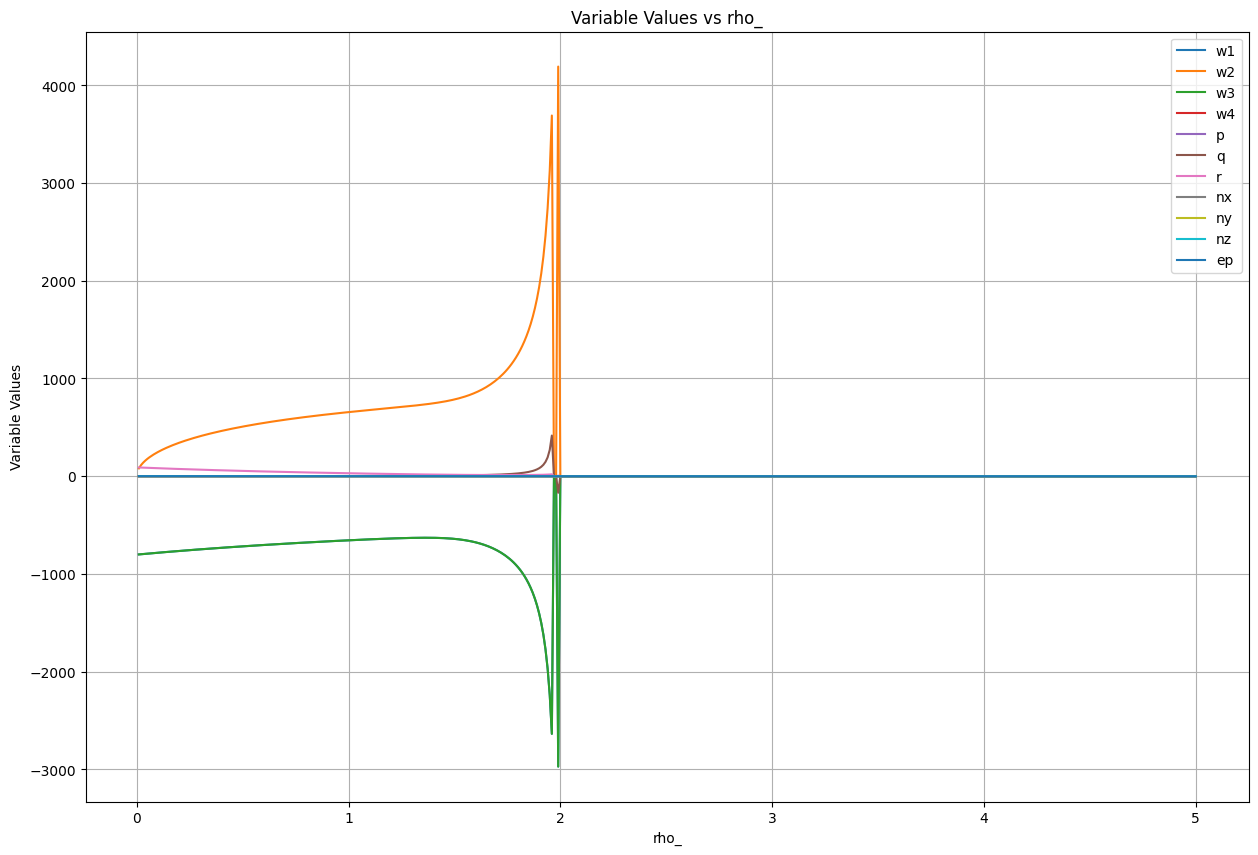

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming solve_equilibrium_equations is defined and accessible
def plot_equilibrium_equations():
    rho_values = np.arange(0.01, 5.01, 0.01)  # rho_ from 0.01 to 5.00
    initial_guess = 0.01  # Initial guess for the first iteration
    results = {key: [] for key in ['w1', 'w2', 'w3', 'w4', 'p', 'q', 'r', 'nx', 'ny', 'nz', 'ep']}
    for rho_ in rho_values:
        __new_sol__ = solve_equilibrium_equations(failed_motor=4, rho_=rho_, initial_guess=initial_guess)
        new_sol = __new_sol__[0]
        obj_sol = __new_sol__[1]
        initial_guess = abs(new_sol['ep'])  # Update initial guess to the last value of ep
        # if not obj_sol.success:
        #     initial_guess = rho_
        for key in results.keys():
            results[key].append(new_sol[key])
    
    # Plot each variable
    plt.figure(figsize=(15, 10))
    for key, values in results.items():
        plt.plot(rho_values, values, label=key)
    # plt.plot(rho_values, results['w1'], label='w1')
    
    plt.xlabel("rho_")
    plt.ylabel("Variable Values")
    plt.title("Variable Values vs rho_")
    plt.legend()
    plt.grid()
    plt.show()
    return results

results = plot_equilibrium_equations()


In [34]:
import numpy as np
import plotly.graph_objects as go

# Assuming solve_equilibrium_equations is defined and accessible
def plot_equilibrium_equations_interactive(columns = ['w1', 'w2', 'w3', 'w4', 'p', 'q', 'r', 'nx', 'ny', 'nz', 'ep']):
    rho_values = np.arange(0.01, 5.01, 0.01)  # rho_ from 0.01 to 5.00
    initial_guess = 0.01  # Initial guess for the first iteration
    results = {key: [] for key in columns}
    
    for rho_ in rho_values:
        __new_sol__ = solve_equilibrium_equations(failed_motor=4, rho_=rho_, initial_guess=initial_guess)
        new_sol = __new_sol__[0]
        obj_sol = __new_sol__[1]
        initial_guess = abs(new_sol['ep'])  # Update initial guess to the last value of ep
        for key in results.keys():
            results[key].append(new_sol[key])
    
    # Create an interactive plot
    fig = go.Figure()
    
    # Add traces for each variable
    for key, values in results.items():
        fig.add_trace(go.Scatter(
            x=rho_values, 
            y=values, 
            mode='lines', 
            name=key, 
            hovertemplate=key+': %{y:.4f} <br> rho_: %{x:.2f}<extra></extra>'
        ))
    
    # Set plot layout
    fig.update_layout(
        title="Variable Values vs rho_ (Interactive)",
        xaxis_title="rho_",
        yaxis_title="Variable Values",
        legend_title="Variables",
        template="plotly_white",
        width=1000,
        height=600
    )
    
    # Show the plot
    fig.show()
    return results

results = plot_equilibrium_equations_interactive()


The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations. for value of initial_guess:  0.002401285460771825  for rho_:  1.97
The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations. for value of initial_guess:  1  for rho_:  1.98
The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations. for value of initial_guess:  0.005906990998671312  for rho_:  2.0
The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations. for value of initial_guess:  1  for rho_:  2.01
The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations. for value of initial_guess:  1  for rho_:  2.02
The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations. for value of initial_guess:  1  for rho_:  2.03
The iteration is not m

/tmp/ipykernel_5640/3347447768.py:34: RuntimeWarning: divide by zero encountered in divide
  w1 = -(mass*9.8*Y / ((4-rho_factor**2) * KF**2 * KT * ep))**(1/4)


In [58]:
plot_equilibrium_equations_interactive(columns=['r', 'q'])

The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations. for value of initial_guess:  0.002401285460771825  for rho_:  1.97
The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations. for value of initial_guess:  1  for rho_:  1.98
The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations. for value of initial_guess:  0.005906990998671312  for rho_:  2.0
The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations. for value of initial_guess:  1  for rho_:  2.01
The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations. for value of initial_guess:  1  for rho_:  2.02
The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations. for value of initial_guess:  1  for rho_:  2.03
The iteration is not m

/tmp/ipykernel_5640/3347447768.py:34: RuntimeWarning:

divide by zero encountered in divide



{'r': [np.float64(89.35991095220474),
  np.float64(88.4707149177924),
  np.float64(87.59028054196949),
  np.float64(86.71847905322086),
  np.float64(85.85518419851155),
  np.float64(85.00027218177355),
  np.float64(84.15362160451801),
  np.float64(83.31511340829917),
  np.float64(82.48463081890532),
  np.float64(81.6620592921903),
  np.float64(80.84728646148004),
  np.float64(80.040202086495),
  np.float64(79.24069800373684),
  np.float64(78.44866807828845),
  np.float64(77.66400815698248),
  np.float64(76.88661602289223),
  np.float64(76.1163913511048),
  np.float64(75.35323566573435),
  np.float64(74.59705229813774),
  np.float64(73.84774634629545),
  np.float64(73.10522463532128),
  np.float64(72.36939567906822),
  np.float64(71.6401696427962),
  np.float64(70.9174583068709),
  np.float64(70.20117503146346),
  np.float64(69.49123472222172),
  np.float64(68.78755379688536),
  np.float64(68.09005015281814),
  np.float64(67.39864313543163),
  np.float64(66.71325350747557),
  np.float64

In [36]:
new_sol = solve_equilibrium_equations(failed_motor=4, rho_=1.36, initial_guess=1)[0]
new_sol

{'w1': np.float64(-629.7929120057333),
 'w2': np.float64(734.4584347239942),
 'w3': np.float64(-629.7929120057333),
 'w4': 0.0,
 'p': np.float64(-0.0),
 'q': np.float64(4.7317317657445965),
 'r': np.float64(17.789740140702264),
 'nx': np.float64(-0.0),
 'ny': np.float64(0.25704390544193),
 'nz': np.float64(0.966399726135702),
 'ep': np.float64(0.0543234312863635)}

In [37]:
# Calculate a_const
a_const = ((Ixx_t - Izz_t) * new_sol['r'] / Ixx_t) + Izz_P * (new_sol['w1'] + new_sol['w2'] + new_sol['w3'] + new_sol['w4']) / Ixx_t

# Define matrices A, B, Q, R
# Define the matrix A without deltat
A = np.array([
    [1,        a_const,  0,        0        ],
    [-a_const, 1,        0,        0        ],
    [0,        -new_sol['nz'],   1,        new_sol['r']     ],
    [new_sol['nz'],    0,        -new_sol['r'],    1        ]
])

B = np.array([
    [0, l / Ixx_t],
    [l / Ixx_t, 0],
    [0, 0],
    [0, 0]
])

# builder = DiagramBuilder()
# system = builder.AddSystem(LinearSystem(A, B, np.zeros((2,)), np.zeros((1,)), time_period=1.0))
# context = system.CreateDefaultContext()

# Ensure Q is symmetric
Q = np.array([
    # [20, 0, 0, 0],
    # [0, 20, 0, 0],
    # [0, 0, 150, 0],     
    # [0, 0, 0, 150]
    [400, 0, 0, 0],
    [0, 4500, 0, 0],
    [0, 0, 1000, 0],        # changed quaternion function, R = [12, 0],[0, 10]
    [0, 0, 0, 1000]
    # [200, 0, 0, 0],
    # [0, 4000, 0, 0],
    # [0, 0, 1000, 0],        
    # [0, 0, 0, 1000]
    
    
    
    # iris
    # [200, 0, 0, 0],
    # [0, 1350, 0, 0],
    # [0, 0, 400, 0],               #BEST: earlier values before changes in quaternion function, good to go R = [2, 0],[0, 1]
    # [0, 0, 0, 400]
    # [40, 0, 0, 0],
    # [0, 40, 0, 0],
    # [0, 0, 800, 0],               #earlier values before changes in quaternion function, good to go R = [2, 0],[0, 1]
    # [0, 0, 0, 800]
    # [1000, 0, 0, 0],
    # [0, 1000, 0, 0],
    # [0, 0, 20000, 0],               #earlier values before changes in quaternion function, good to go R = [2, 0],[0, 1]
    # [0, 0, 0, 20000]
    # [2500, 0, 0, 0],
    # [0, 2500, 0, 0],
    # [0, 0, 2000, 0],               #earlier values before changes in quaternion function, good to go R = [2, 0],[0, 1]
    # [0, 0, 0, 2000]
    # [200, 0, 0, 0],
    # [0, 1300, 0, 0],
    # [0, 0, 400, 0],               #earlier values before changes in quaternion function, good to go R = [2, 0],[0, 1]
    # [0, 0, 0, 400]
    # [200, 0, 0, 0],
    # [0, 1250, 0, 0],
    # [0, 0, 200, 0],               #earlier values before changes in quaternion function, good to go R = [5, 1], [1, 4], 4000hz, 100hz
    # [0, 0, 0, 200]
    # [200, 0, 0, 0],
    # [0, 800, 0, 0],
    # [0, 0, 200, 0],               #earlier values before changes in quaternion function, good to go R = [2, 0],[0, 1]
    # [0, 0, 0, 200]
    # [80, 0, 0, 0],
    # [0, 800, 0, 0],
    # [0, 0, 200, 0],               #earlier values before changes in quaternion function, good to go R = [2, 0],[0, 1]
    # [0, 0, 0, 200]
    # [20, 0, 0, 0],
    # [0, 800, 0, 0],
    # [0, 0, 200, 0],               #earlier values before changes in quaternion function, good to go R = [2, 0],[0, 1]
    # [0, 0, 0, 200]
    
    # [1000, 0, 0, 0],
    # [0, 1000, 0, 0],
    # [0, 0, 500, 0],
    # [0, 0, 0, 500]
    
    
    # [500, 0, 0, 0],
    # [0, 80, 0, 0],
    # [0, 0, 800, 0],
    # [0, 0, 0, 5000]
    # [400, 0, 0, 0],
    # [0, 50, 0, 0],
    # [0, 0, 500, 0],
    # [0, 0, 0, 4000]
    # [250, 0, 0, 0],
    # [0, 40, 0, 0],
    # [0, 0, 400, 0],
    # [0, 0, 0, 800]
    # [20, 0, 0, 0],
    # [0, 50, 0, 0],
    # [0, 0, 200, 0],
    # [0, 0, 0, 500]
])

R = np.array([
    # [5, 0],
    # [0, 5]
    # [35, 0],
    # [0, 35]
    
    
    # [12, 0],
    # [0, 10]
    # [11, 0],
    # [0, 10]
    
    # iris
    # [1, 0],
    # [0, 1]
    # [2.5, 0],
    # [0, 2.5]
    [5, 1],             #best
    [1, 4]
    # [5.5, 1],
    # [1, 4]
    # [4, 1],
    # [1, 3]
    # [2, 0],
    # [0, 1]
    
    
])

# Calculate the LQR gain
# result = DiscreteTimeLinearQuadraticRegulator(A, B, Q, R)
result = LinearQuadraticRegulator(A, B, Q, R)


# Print the result[0] in C++ style initialization format
# result_cpp_format = "K = {" + ",".join(
#     [" {" + ", ".join(f"{x:.8e}" for x in row) + "} " for row in result[0]]
# ) + "}; "
# print(result_cpp_format)
print('K = {{', ", ".join(map(str, result[0][0])), '}, \n     {', ", ".join(map(str, result[0][1])) , '}};')



K = {{ 0.6499886885380609, 30.524939466702527, -13.259084575292187, -9.901318193350985 }, 
     { 11.263456784281491, -4.002884809932686, -5.9089706106170246, 50.754005570408054 }};


In [38]:
K_gain = result[0]
M = A - np.dot(B, K_gain)
eigenvalues = np.linalg.eigvals(M)
print("Eigenvalues of A - BK:", eigenvalues)

Eigenvalues of A - BK: [-267.4955294  +0.j          -92.05821061 +0.j
   -1.45843107+17.79237946j   -1.45843107-17.79237946j]


In [39]:
Radius = math.sqrt(1-new_sol['nz']**2) * 9.81 / (new_sol['nz'] * (new_sol['p']**2 + new_sol['q']**2 + new_sol['r']**2))
Radius

np.float64(0.00770005643407351)

In [40]:
2*math.pi / math.sqrt(new_sol['p']**2 + new_sol['q']**2 + new_sol['r']**2)

0.34132418529405906

In [41]:
# Eigenvalues of A - BK: [-7.16259795+14.96669237j -7.16259795-14.96669237j
#  -1.04639979+11.69775014j -1.04639979-11.69775014j]

In [57]:
a_const = ((Ixx_t - Izz_t) * new_sol['r'] / Ixx_t) + Izz_P * (new_sol['w1'] + new_sol['w2'] + new_sol['w3'] + new_sol['w4']) / Ixx_t
A = np.array([
    [1,        a_const,  0,        0        ],
    [-a_const, 1,        0,        0        ],
    [0,        -new_sol['nz'],   1,        new_sol['r']     ],
    [new_sol['nz'],    0,        -new_sol['r'],    1        ]
])

B = np.array([
    [0, l / Ixx_t],
    [l / Ixx_t, 0],
    [0, 0],
    [0, 0]
])

Q = np.array([
    # [500, 0, 0, 0],
    # [0, 1800, 200, 0],
    # [0, 200, 1000, 0],               #BEST: earlier values before changes in quaternion function, good to go R = [9, 0],[0, 8]
    # [0, 0, 0, 1000]
    
    [1400, 0, 0, 0],
    [0, 1800, 200, 0],
    [0, 200, 1000, 0],               #BEST: earlier values before changes in quaternion function, good to go R = [9, 0],[0, 8]
    [0, 0, 0, 1000]
    #################################################
    # [1200, 0, 0, 0],
    # [0, 1200, 0, 0],
    # [0, 0, 2000, 0],               #BEST: earlier values before changes in quaternion function, good to go R = [9, 0],[0, 8]
    # [0, 0, 0, 2000]
    
    
    
    
    
    
    
    ################################################
    # [1200, 0, 0, 0],
    # [0, 500, 0, 0],
    # [0, 0, 1000, 0],               #BEST: earlier values before changes in quaternion function, good to go R = [9, 0],[0, 8]
    # [0, 0, 0, 1000]
    # [1200, 0, 0, 0],
    # [0, 2000, 0, 0],
    # [0, 0, 1000, 0],               #BEST: earlier values before changes in quaternion function, good to go R = [9, 0],[0, 8]
    # [0, 0, 0, 1000]
    # [900, 0, 0, 0],
    # [0, 1600, 0, 0],
    # [0, 0, 800, 0],               #BEST: earlier values before changes in quaternion function, good to go R = [9, 0],[0, 8]
    # [0, 0, 0, 800]
    
    
    
    # [40, 0, 0, 0],
    # [0, 150, 0, 0],
    # [0, 0, 800, 0],               #earlier values before changes in quaternion function, good to go R = [2, 0],[0, 1]
    # [0, 0, 0, 800]
    # [1000, 0, 0, 0],
    # [0, 1000, 0, 0],
    # [0, 0, 20000, 0],               #earlier values before changes in quaternion function, good to go R = [2, 0],[0, 1]
    # [0, 0, 0, 20000]
    # [2500, 0, 0, 0],
    # [0, 2500, 0, 0],
    # [0, 0, 2000, 0],               #earlier values before changes in quaternion function, good to go R = [2, 0],[0, 1]
    # [0, 0, 0, 2000]
    
    # [1000, 0, 0, 0],
    # [0, 1000, 0, 0],
    # [0, 0, 500, 0],
    # [0, 0, 0, 500]
    
    # [20, 0, 0, 0],
    # [0, 20, 0, 0],
    # [0, 0, 200, 0],
    # [0, 0, 0, 500]
])

R = np.array([
    # [6, 0],             #best
    # [0, 8]
    # [8, 1],
    # [1, 7]
    # [3, 0],
    # [0, 2]
    # [2, 0],
    # [0, 1]
    
    # [12, 1],
    # [1, 11]
    [11, 1],         # x, y, 0, 0
    [1, 10]
    ############################################
    # [9, 1],
    # [1, 8]
    
])

# Calculate the LQR gain
# result = DiscreteTimeLinearQuadraticRegulator(A, B, Q, R)
result = LinearQuadraticRegulator(A, B, Q, R)


# Print the result[0] in C++ style initialization format
# result_cpp_format = "K = {" + ",".join(
#     [" {" + ", ".join(f"{x:.8e}" for x in row) + "} " for row in result[0]]
# ) + "}; "
# print(result_cpp_format)
print('K = {{', ", ".join(map(str, result[0][0])), '}, \n     {', ", ".join(map(str, result[0][1])) , '}};')

K_gain = result[0]

M = A - np.dot(B, K_gain)
eigenvalues = np.linalg.eigvals(M)
print("Eigenvalues of A - BK:", eigenvalues)


K = {{ -0.37411555954446124, 13.023960916126605, -25.61061624374246, -11.921944552854015 }, 
     { 12.436213546065465, -0.47030185250502166, -9.098541674122346, 32.82293270509998 }};
Eigenvalues of A - BK: [-108.36816731+20.57488695j -108.36816731-20.57488695j
   -1.27054467+17.79155014j   -1.27054467-17.79155014j]


In [43]:
#     [1000, 0, 0, 0],
#     [0, 1000, 0, 0],
#     [0, 0, 500, 0],
#     [0, 0, 0, 500]
#         [4, 1],
#     [1, 3]
#     K = {{ -2.582428420135099, 16.267722362765888, -36.1612717711584, -16.4116314277622 }, 
#      { 19.677777106884477, -2.3065529788072694, -5.544821833598845, 43.7861471723406 }};
# Eigenvalues of A - BK: [-165.13730795 +0.j         -143.69216702 +0.j
#    -1.20041429+18.87249673j   -1.20041429-18.87249673j]

In [44]:
import numpy as np
from scipy.linalg import solve_continuous_are
from scipy.linalg import eigvals
from scipy.signal import place_poles

desired_poles = np.array([-5 + 13j, -5 - 13j, -5 + 13j, -5 - 13j])
0
# Compute the gain matrix K using pole placement
place = place_poles(A, B, desired_poles)
K = place.gain_matrix
print('K = {{', ", ".join(map(str, K[0])), '}, \n     {', ", ".join(map(str, K[1])) , '}};')

# Print the new poles of the system A - BK
eigenvalues = eigvals(A - B @ K)
print("New eigenvalues of A - BK:", eigenvalues)


K = {{ 0.4254447120143117, 1.3683519279809286, 13.153359115761281, -25.18898191036091 }, 
     { 1.3683519279809733, -0.425444712014315, -25.18898191036109, -13.153359115760988 }};
New eigenvalues of A - BK: [-5.+13.j -5.-13.j -5.+13.j -5.-13.j]


In [45]:
damping_const = math.sqrt(1.08770736**2/(1.08770736**2 + 11.69814094**2))
natural_freq = 1.08770736 / damping_const
natural_freq_hz = natural_freq / math.pi
damping_const, natural_freq, natural_freq_hz

(0.09258186790207677, 11.748600289102622, 3.739695620843106)

In [46]:
## for normal drone setup 
# Q = [[10, 0, 0, 0],
    # [0, 10, 0, 0],
    # [0, 0, 100, 0],
    # [0, 0, 0, 100]]
# R = [
    # [1, 0],
    # [0, 1]
# ]



# iris
# Q = np.array([
#     [20, 0, 0, 0],
#     [0, 20, 0, 0],
#     [0, 0, 150, 0],       descent
#     [0, 0, 0, 150]
#         [1, 0],
#     [0, 1]

    # [20, 0, 0, 0],
    # [0, 100, 0, 0],
    # [0, 0, 200, 0],       good to go
    # [0, 0, 0, 200]





    # [400, 0, 0, 0],
    # [0, 400, 0, 0],
    # [0, 0, 400, 0],       too much minor osc
    # [0, 0, 0, 400]
    # [200, 0, 0, 0],
    # [0, 200, 0, 0],       less osc but good
    # [0, 0, 200, 0],
    # [0, 0, 0, 200]
    # [1, 0],
    # [0, 1]

In [47]:
a_const = ((Ixx_t - Izz_t) * new_sol['r'] / Ixx_t) + Izz_P * (
    new_sol['w1'] + new_sol['w2'] + new_sol['w3'] + new_sol['w4']
) / Ixx_t
b_const = (Ixx_t - Izz_t) * new_sol['q'] / Ixx_t
c_const = (Izz_t - Ixx_t) * new_sol['p'] / Ixx_t
d_const = -Y / Izz_t

A = np.array(
    [
        [1, a_const, b_const, 0, 0],
        [-a_const, 1, c_const, 0, 0],
        [0, 0, d_const + 1, 0, 0],
        [0, -new_sol['nz'], new_sol['ny'], 1, new_sol['r']],
        [new_sol['nz'], 0, -new_sol['nx'], -new_sol['r'], 1],
    ]
)

B = np.array(
    [
        [0, l / Ixx_t, 0],
        [-l / Ixx_t, 0, l / Ixx_t],
        [KT / Izz_t, -KT / Izz_t, KT / Izz_t],
        [0, 0, 0],
        [0, 0, 0],
    ]
)
Q = np.array([
    # iris
        [300, 0, 0, 300, 0],
        [0, 100, 0, 0, 0],
        [0, 0, 500, 0, 0],
        [300, 0, 0, 900, 0],
        [0, 0, 0, 0, 500],
])

R = np.array([
    # iris
        [500, 0, 0],
        [0, 500, 0],
        [0, 0, 500],
])

result = LinearQuadraticRegulator(A, B, Q, R)
result_cpp_format = (
    "K = {\n"
    + ",\n".join(
        ["  {" + ", ".join(f"{x:.8e}" for x in row) + "}" for row in result[0]]
    )
    + "\n};"
)

print(result_cpp_format)

K = {
  {9.07556373e-02, -7.08305048e-01, 1.02912055e+00, 8.86757184e-01, 5.70408291e+00},
  {8.97624614e-01, -7.01939858e-02, -8.59838850e-01, -8.64765477e+00, 1.67836880e+00},
  {-8.21543181e-02, 6.75783065e-01, 7.61370817e-01, -7.57183888e-01, -5.07395290e+00}
};


In [48]:
result

(array([[ 0.09075564, -0.70830505,  1.02912055,  0.88675718,  5.70408291],
        [ 0.89762461, -0.07019399, -0.85983885, -8.64765477,  1.6783688 ],
        [-0.08215432,  0.67578306,  0.76137082, -0.75718389, -5.0739529 ]]),
 array([[ 5.14229661e+01, -4.92920148e+00,  2.01870868e+00,
         -4.89349339e+02,  1.13654958e+02],
        [-4.92920148e+00,  3.94566591e+01, -7.63283045e+00,
         -4.68643736e+01, -3.07253043e+02],
        [ 2.01870868e+00, -7.63283045e+00,  4.20223967e+02,
          3.04105373e+01,  1.47889980e+02],
        [-4.89349339e+02, -4.68643736e+01,  3.04105373e+01,
          1.67319741e+04, -1.04185085e+02],
        [ 1.13654958e+02, -3.07253043e+02,  1.47889980e+02,
         -1.04185085e+02,  1.68780460e+04]]))

In [49]:
f1 = KF * new_sol['w1'] * new_sol['w1']
f2 = KF * new_sol['w2'] * new_sol['w2']
f3 = KF * new_sol['w3'] * new_sol['w3']
f4 = KF * new_sol['w4'] * new_sol['w4']
f1, f2, f3, f4, f1+f2+f3+f4

(np.float64(4.632744828307885),
 np.float64(6.300532966498725),
 np.float64(4.632744828307885),
 0.0,
 np.float64(15.566022623114495))

In [50]:
max_f = KF * 1100**2
# max_f = KF * 1100**2
max_f, max_f/2, 

(14.1328, 7.0664)

In [51]:
mass * 9.81

15.05835

In [52]:
# bkcd
del_z = 0.01
(1+math.exp(del_z))**2 / (2*(8.83-1.5)*math.exp(del_z))

0.2728581173829015

In [53]:
import numpy as np
import plotly.graph_objects as go

# Define the function to plot
def function(x):
    return np.sin(x)

# Generate x and y values
x = np.linspace(-10, 10, 500)
y = function(x)

# Create the interactive plot
fig = go.Figure()

# Add a trace for the function
fig.add_trace(go.Scatter(
    x=x, 
    y=y, 
    mode='lines', 
    line=dict(color='blue'),
    name="y = sin(x)",
    hovertemplate='x: %{x:.2f}<br>y: %{y:.2f}'
))

# Customize layout to look like Desmos
fig.update_layout(
    title="Desmos-like Interactive Plot",
    xaxis=dict(
        title="X-axis",
        zeroline=True,
        showgrid=True,
        linecolor='black',
        mirror=True
    ),
    yaxis=dict(
        title="Y-axis",
        zeroline=True,
        showgrid=True,
        linecolor='black',
        mirror=True
    ),
    plot_bgcolor="white",
    width=800,
    height=600
)

# Show the plot
fig.show()
